In [2]:
import pandas as pd
from prophet import Prophet

c:\Users\sarah\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


# Análise exploratória

In [3]:
#Carregamento da base
df = pd.read_csv('DailyDelhiClimateTrain.csv')
df.head(20)

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
5,2013-01-06,7.000000,82.800000,1.480000,1018.000000
6,2013-01-07,7.000000,78.600000,6.300000,1020.000000
7,2013-01-08,8.857143,63.714286,7.142857,1018.714286
8,2013-01-09,14.000000,51.250000,12.500000,1017.000000
9,2013-01-10,11.000000,62.000000,7.400000,1015.666667


In [4]:
#Verificando tamanho
df.shape

(1462, 5)

In [5]:
#Verificando valores nulos
print(df.isnull().sum().to_string())

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0


In [6]:
#Verificando valores duplicados
df.duplicated().sum()

np.int64(0)

In [7]:
#Verificando estatísticas descritivas
df.describe().round(2)

,meantemp,humidity,wind_speed,meanpressure
count,1462.00,1462.00,1462.00,1462.00
mean,25.50,60.77,6.80,1011.10
std,7.35,16.77,4.56,180.23
min,6.00,13.43,0.00,-3.04
25%,18.86,50.38,3.48,1001.58
50%,27.71,62.62,6.22,1008.56
75%,31.31,72.22,9.24,1014.94
max,38.71,100.00,42.22,7679.33


In [8]:
#Verificando datas únicas
print(df['date'].unique())

<StringArray>
['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
 '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09', '2013-01-10',
 ...
 '2016-12-23', '2016-12-24', '2016-12-25', '2016-12-26', '2016-12-27',
 '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31', '2017-01-01']
Length: 1462, dtype: str


In [9]:
#Investigando outliers na pressão
print('Valores suspeitos em meanpressure:')
print(df[df['meanpressure'] > 1100][['date', 'meanpressure']])
print()
print(df[df['meanpressure'] < 900][['date', 'meanpressure']])

Valores suspeitos em meanpressure:
            date  meanpressure
1182  2016-03-28   7679.333333
1362  2016-09-24   1352.615385
1416  2016-11-17   1350.296296

            date  meanpressure
1309  2016-08-02    310.437500
1321  2016-08-14    633.900000
1323  2016-08-16     -3.041667
1427  2016-11-28     12.045455


In [10]:
#Corrigindo outliers na meanpressure
mediana_pressao = df[(df['meanpressure'] >= 900) & (df['meanpressure'] <= 1100)]['meanpressure'].median()

df.loc[df['meanpressure'] > 1100, 'meanpressure'] = mediana_pressao
df.loc[df['meanpressure'] < 900, 'meanpressure'] = mediana_pressao

print(f'Mediana usada para substituição: {mediana_pressao:.2f}')
print(f'Novo máximo: {df["meanpressure"].max():.2f}')
print(f'Novo mínimo: {df["meanpressure"].min():.2f}')

Mediana usada para substituição: 1008.57
Novo máximo: 1023.00
Novo mínimo: 938.07


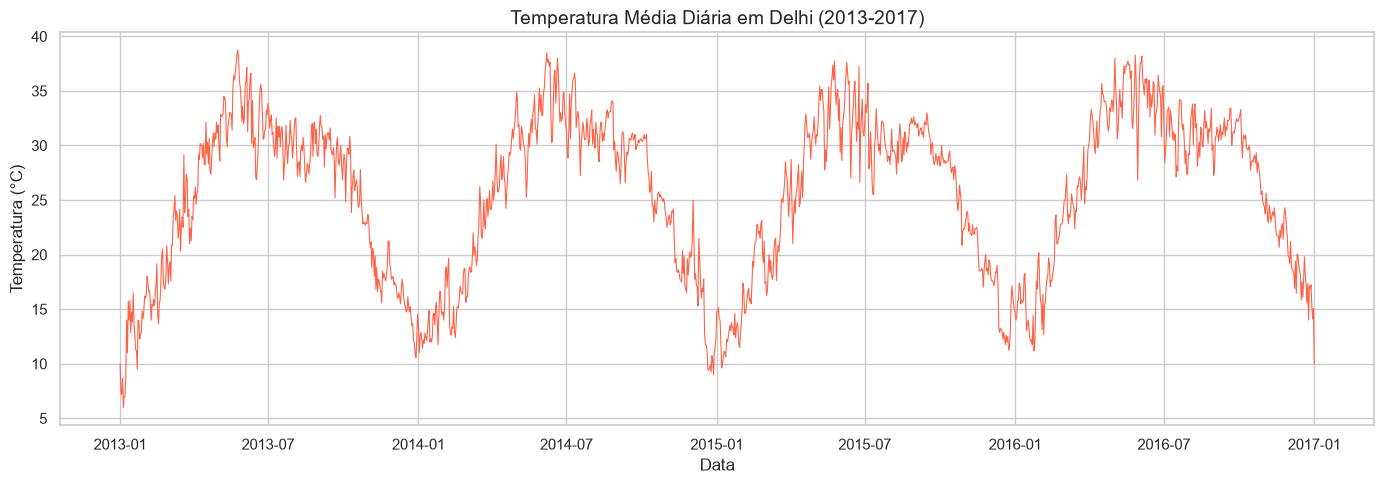

In [22]:
#Analisando a temperatura ao longo do tempo
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['meantemp'], color='tomato', linewidth=0.8)
plt.title('Temperatura Média Diária em Delhi (2013-2017)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Temperatura (°C)')
plt.tight_layout()
plt.show()

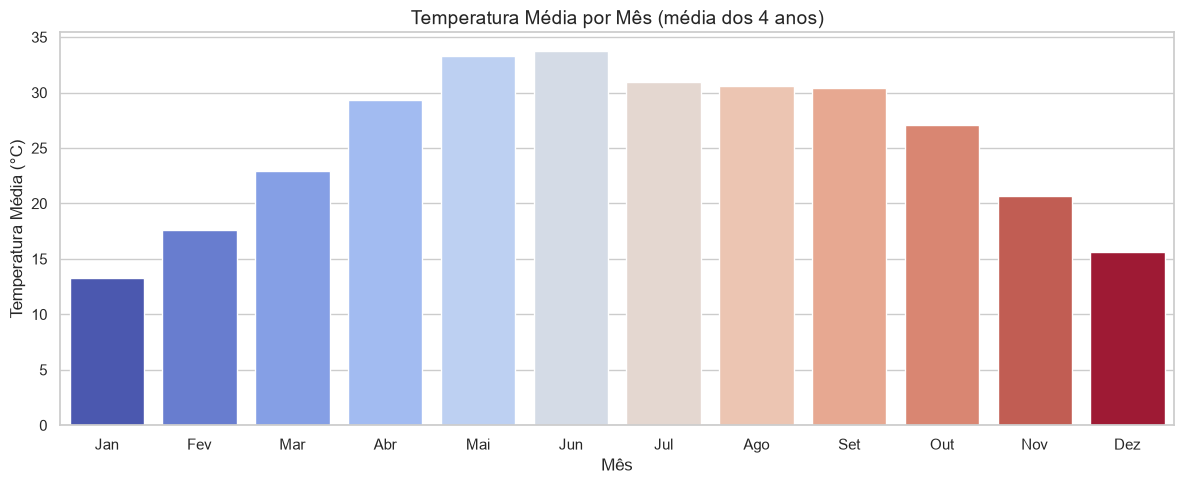

In [12]:
#Analisando a média mensal de temperatura
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

media_mensal = df.groupby('month')['meantemp'].mean()

plt.figure(figsize=(12, 5))
sns.barplot(x=media_mensal.index, y=media_mensal.values,
            hue=media_mensal.index, palette='coolwarm', legend=False)
plt.title('Temperatura Média por Mês (média dos 4 anos)', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Temperatura Média (°C)')
plt.xticks(ticks=range(12), labels=['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
plt.tight_layout()
plt.show()

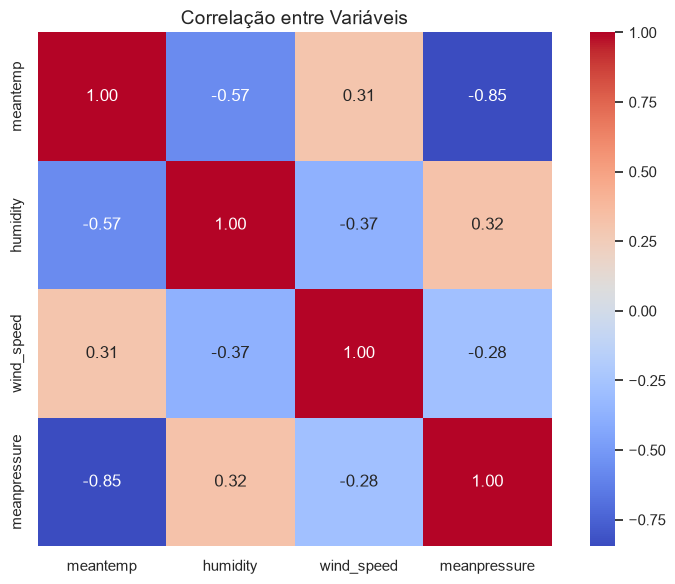

In [13]:
#Analisando a correlação entre as variáveis
plt.figure(figsize=(8, 6))
sns.heatmap(df[['meantemp','humidity','wind_speed','meanpressure']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlação entre Variáveis', fontsize=14)
plt.tight_layout()
plt.show()

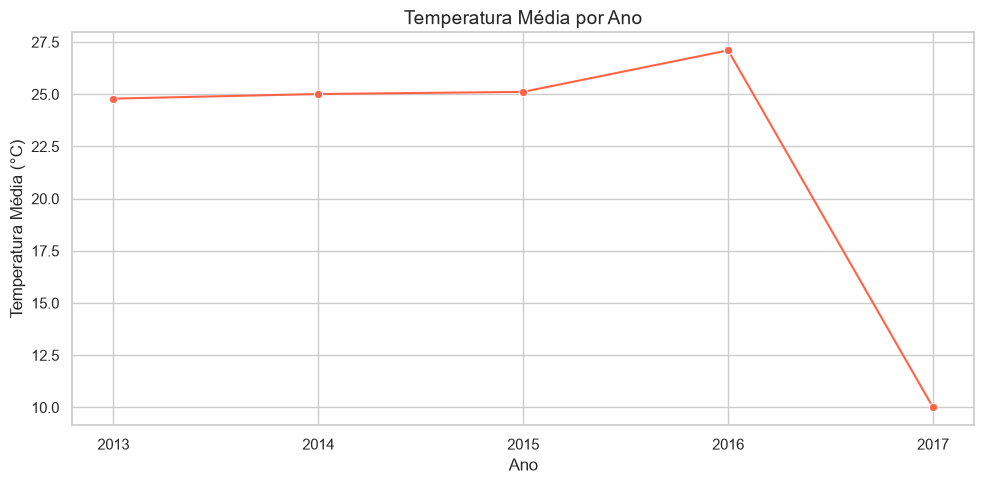

In [14]:
#Temperatura média por ano
media_anual = df.groupby('year')['meantemp'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=media_anual.index, y=media_anual.values, marker='o', color='tomato')
plt.title('Temperatura Média por Ano', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Temperatura Média (°C)')
plt.xticks([2013, 2014, 2015, 2016, 2017])
plt.tight_layout()
plt.show()

# Modelo de Previsão - Prophet

In [ ]:
#Fazendo a transformação dos dados para o formato esperado pelo Prophet
df_prophet = df[['date', 'meantemp']].rename(columns={'date': 'ds', 'meantemp': 'y'})
df_prophet.head()

,ds,y
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


In [ ]:
#Aplicando o modelo nos dados
modelo = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
modelo.fit(df_prophet)
print(' Modelo treinado com sucesso!')

19:45:58 - cmdstanpy - INFO - Chain [1] start processing
19:46:00 - cmdstanpy - INFO - Chain [1] done processing


 Modelo treinado com sucesso!


In [ ]:
#Gerando previsões para os próximos 120 dias
futuro = modelo.make_future_dataframe(periods=120)
previsao = modelo.predict(futuro)
previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
1572,2017-04-22,33.204249,30.577056,35.848309
1573,2017-04-23,33.376833,30.722310,35.971468
1574,2017-04-24,33.543104,30.952329,36.140855
1575,2017-04-25,33.702600,31.095963,36.314012
1576,2017-04-26,33.854962,31.130449,36.422300
1577,2017-04-27,33.999949,31.396754,36.508618
1578,2017-04-28,34.137452,31.528021,36.781980
1579,2017-04-29,34.267496,31.678334,36.881513
1580,2017-04-30,34.390245,31.854170,36.885235
1581,2017-05-01,34.506004,32.040881,37.052904


# Resultado da previsão

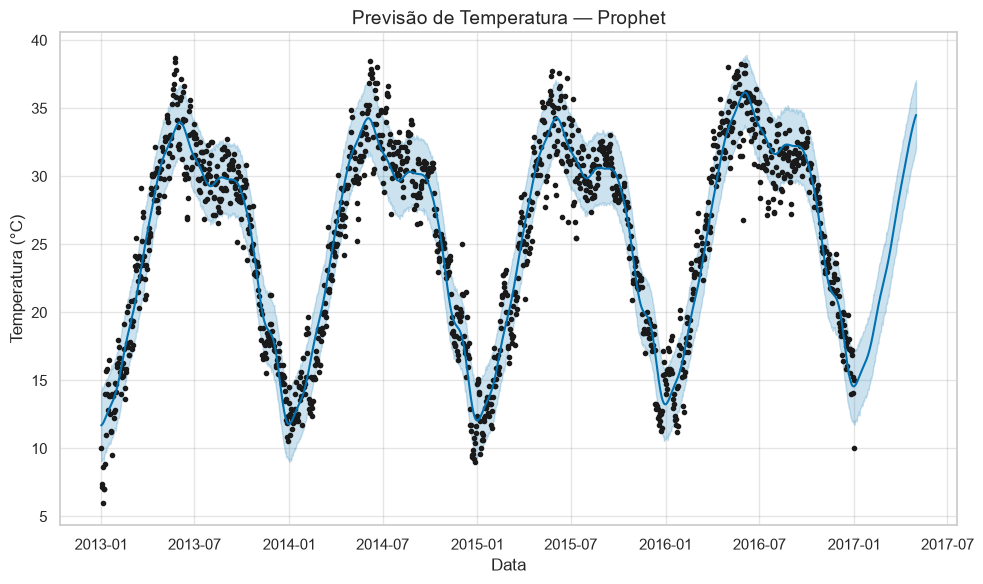

In [18]:
fig1 = modelo.plot(previsao)
plt.title('Previsão de Temperatura — Prophet', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Temperatura (°C)')
plt.tight_layout()
plt.show()

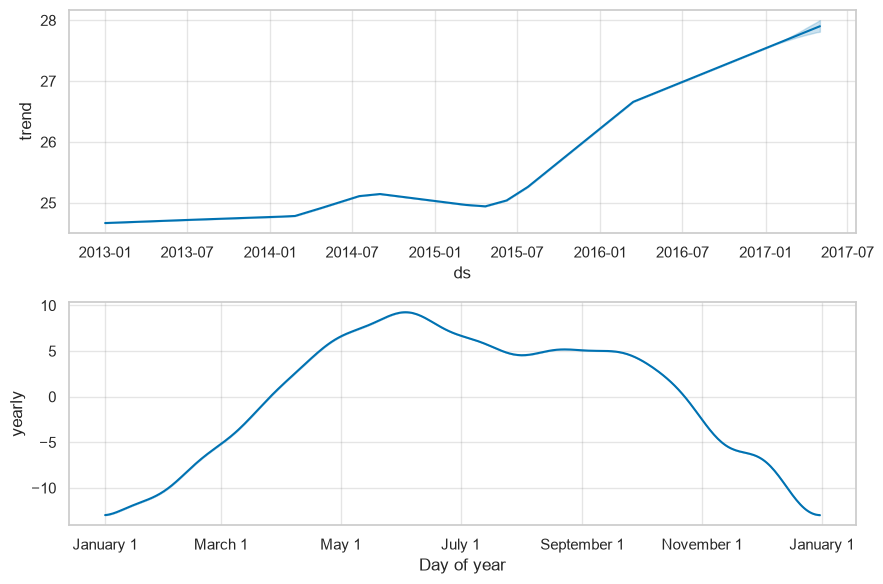

In [19]:
fig2 = modelo.plot_components(previsao)
plt.tight_layout()
plt.show()

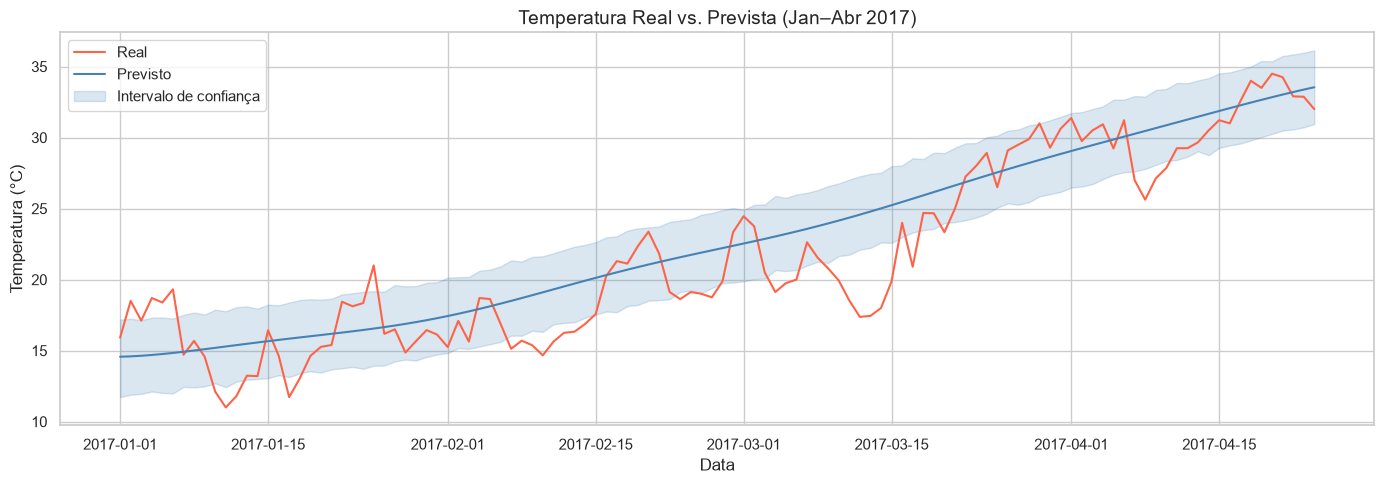

In [20]:
#Comparando a previsão feita com dados da base de Teste
df_test = pd.read_csv('DailyDelhiClimateTest.csv')
df_test['date'] = pd.to_datetime(df_test['date'])

previsao_test = previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
previsao_test = previsao_test[previsao_test['ds'].isin(df_test['date'])]

plt.figure(figsize=(14, 5))
plt.plot(df_test['date'], df_test['meantemp'], color='tomato', label='Real', linewidth=1.5)
plt.plot(previsao_test['ds'], previsao_test['yhat'], color='steelblue', label='Previsto', linewidth=1.5)
plt.fill_between(previsao_test['ds'], previsao_test['yhat_lower'], previsao_test['yhat_upper'],
                 alpha=0.2, color='steelblue', label='Intervalo de confiança')
plt.title('Temperatura Real vs. Prevista (Jan–Abr 2017)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

#Juntando previsão com valores reais
df_eval = previsao_test.merge(df_test[['date', 'meantemp']], left_on='ds', right_on='date')

mae  = mean_absolute_error(df_eval['meantemp'], df_eval['yhat'])
rmse = np.sqrt(mean_squared_error(df_eval['meantemp'], df_eval['yhat']))

print('=== MÉTRICAS DE AVALIAÇÃO ===')
print(f'MAE  (Erro Médio Absoluto):      {mae:.2f}°C')
print(f'RMSE (Raiz do Erro Quadrático):  {rmse:.2f}°C')
print()
print('Interpretação:')
print(f'   O modelo erra em média {mae:.2f}°C na previsão da temperatura.')

=== MÉTRICAS DE AVALIAÇÃO ===
MAE  (Erro Médio Absoluto):      2.20°C
RMSE (Raiz do Erro Quadrático):  2.68°C

Interpretação:
   O modelo erra em média 2.20°C na previsão da temperatura.


#  Conclusão

Este projeto demonstrou que o **Prophet** é uma ferramenta poderosa para previsão de séries temporais climáticas, capturando com precisão a sazonalidade anual de Delhi.

## Principais aprendizados da EDA
- A temperatura de Delhi segue um padrão sazonal muito definido: **inverno frio** (jan/dez abaixo de 15°C), **verão quente** (mai/jun acima de 32°C) e monção com queda de temperatura em jul/ago
- A tendência ao longo dos anos (2013–2017) se manteve **estável**, sem aquecimento ou resfriamento expressivo no período
- **Umidade e temperatura** têm correlação negativa — os meses mais secos são os mais quentes
- Foram encontrados **7 registros com valores impossíveis** na pressão atmosférica (incluindo pressão negativa e valor de 7679 hPa), todos corrigidos com a mediana dos valores válidos

## Desempenho do modelo

| Métrica | Valor |
|---------|-------|
| MAE | **2.20°C** |
| RMSE | **2.68°C** |

O modelo erra em média **2.2°C** numa escala de variação de 33°C — um resultado muito bom considerando que usou **apenas o histórico de temperatura** como entrada, sem variáveis externas como umidade ou vento.

## Próximos passos possíveis
- Incluir **regressores externos** no Prophet (umidade, vento) para tentar reduzir o erro
- Avaliar o modelo em um período de teste mais longo
- Comparar o Prophet com outros modelos de séries temporais como ARIMA ou LSTM